### Look at natural variation across topsoils

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO = 'K00370'
annotation = pd.read_csv(f'../data/dmndv0_s_{KO}_rep_q_topsoil_e_1e-5_pid_50.tsv', sep = '\t', header = None).values
sequences = pd
print(annotation.shape)

for i in range(10):
    print(annotation[i])
    


In [ ]:
import gzip

# Read annotations and get unique sequence IDs
annotations = pd.read_csv('../data/topsoil/dmndv0_s_K00370_rep_q_topsoil_e_1e-5_pid_50.tsv', 
                         sep='\t', header=None)
unique_annotations = annotations.drop_duplicates(subset=0)  # Keep first occurrence per sequence ID
unique_ids = set(unique_annotations[0])

# Write unique annotations to file
unique_annotations.to_csv('../data/topsoil/K00370_unique_annotations.tsv', sep='\t', header=False, index=False)

# Filter FASTA sequences
with gzip.open('../data/raw_data/topsoil/compl.incompl.95.prot.faa.gz', 'rt') as f_in, \
     open('../data/topsoil/K00370_annotated_sequences.faa', 'w') as f_out:
    
    print_sequence = False
    current_id = ""
    
    for line in f_in:
        if line.startswith('>'):
            # Extract sequence ID (remove '>' and any additional info)
            current_id = line[1:].split()[0]
            print_sequence = current_id in unique_ids
        
        if print_sequence:
            f_out.write(line)

In [ ]:

def filter_fasta_by_length(input_fasta, output_fasta, min_length=1000):
    """
    Filter FASTA file by sequence length
    """
    sequences_kept = 0
    total_sequences = 0
    
    with open(input_fasta, 'r') as f_in, open(output_fasta, 'w') as f_out:
        current_header = ""
        current_sequence = ""
        
        for line in f_in:
            if line.startswith('>'):
                # Process the previous sequence before starting new one
                if current_header and len(current_sequence) >= min_length:
                    f_out.write(current_header + current_sequence)
                    sequences_kept += 1
                
                # Start new sequence
                current_header = line
                current_sequence = ""
                total_sequences += 1
            else:
                current_sequence += line
        
        # Don't forget the last sequence
        if current_header and len(current_sequence) >= min_length:
            f_out.write(current_header + current_sequence)
            sequences_kept += 1
    
    print(f"Total sequences: {total_sequences}")
    print(f"Sequences kept (length >= {min_length}): {sequences_kept}")
    print(f"Filtered FASTA saved to: {output_fasta}")


filter_fasta_by_length('../data/topsoil/K00370_annotated_sequences.faa', '../data/topsoil/K00370_sequences_min1000aa.faa', 1000)

Total sequences: 12700
Sequences kept (length >= 1000): 120
Filtered FASTA saved to: ../data/topsoil/K00370_sequences_min1000aa.faa


In [ ]:
from Bio import SeqIO
from Bio import pairwise2


# Load sequences
sequences = {}
for record in SeqIO.parse("../data/topsoil/K00370_sequences_min1000aa.faa", "fasta"):
    sequences[record.id] = str(record.seq)

seq_ids = list(sequences.keys())
n_seqs = len(seq_ids)

# Create alignment matrix
alignment_matrix = np.zeros((n_seqs, n_seqs))

print(f"Creating {n_seqs}x{n_seqs} alignment matrix...")

for i in range(n_seqs):
    for j in range(i, n_seqs):  # Only compute upper triangle + diagonal
        if i == j:
            # Self-alignment: score = sequence length
            alignment_matrix[i, j] = len(sequences[seq_ids[i]])
        else:
            # Pairwise alignment
            alignments = pairwise2.align.globalxx(sequences[seq_ids[i]], sequences[seq_ids[j]])
            alignment_matrix[i, j] = alignments[0][2]  # Get the score
            alignment_matrix[j, i] = alignment_matrix[i, j]  # Make symmetric

# Save as CSV with sequence IDs as row/column headers
matrix_df = pd.DataFrame(alignment_matrix, index=seq_ids, columns=seq_ids)
matrix_df.to_csv("../data/topsoil/alignment_matrix.tsv")

print(f"Alignment matrix saved to 'alignment_matrix.tsv'")
print(f"Matrix shape: {alignment_matrix.shape}")

Creating 120x120 alignment matrix...
Alignment matrix saved to 'alignment_matrix.tsv'
Matrix shape: (120, 120)


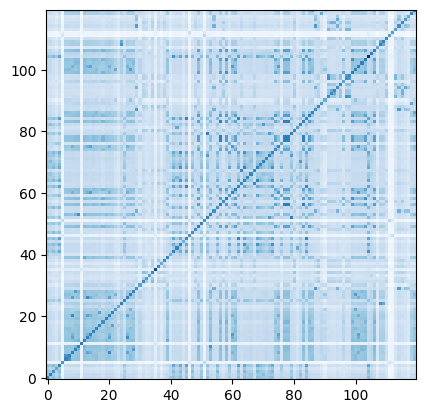

In [ ]:
plt.imshow(alignment_matrix, cmap = 'Blues', origin = 'lower')
np.savetxt('../data/topsoil/alignment_matrix_min1000.tsv', alignment_matrix, delimiter='\t', fmt='%0.0f')

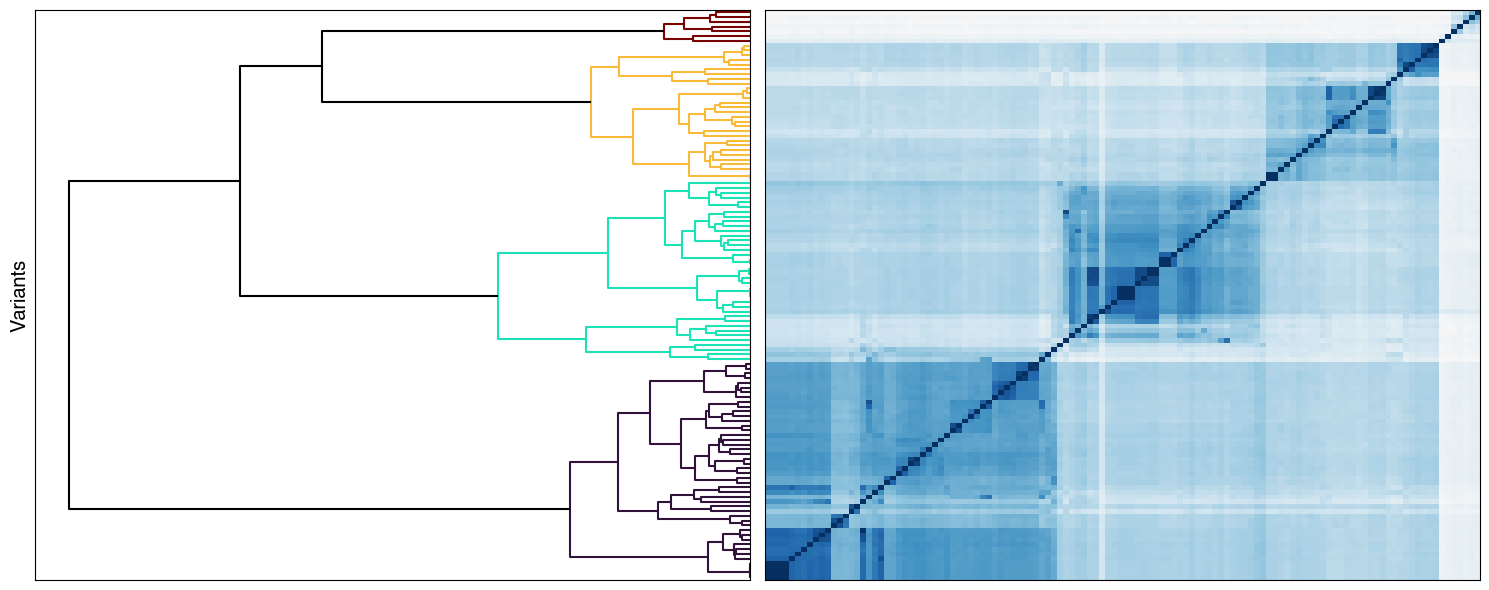

In [32]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()

alignment_matrix = pd.read_csv('../data/topsoil/alignment_matrix_min1000.tsv', sep = '\t', header = None).values

alignment_matrix = scaler.fit_transform(alignment_matrix)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 4
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin = -1, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])
plt.tight_layout()

    
plt.show()
    